In [1]:
import os
import warnings
warnings.filterwarnings("ignore")
from typing import Annotated , List , Literal
from research_analysis.utils.model_loader import ModelLoader
from langgraph.graph import StateGraph, START, END , MessagesState
from langchain_core.messages import AIMessage, HumanMessage , SystemMessage
from langgraph.checkpoint.memory import MemorySaver

In [2]:
from dotenv import load_dotenv
load_dotenv()

True

In [3]:
model_loader = ModelLoader()

{"timestamp": "2026-01-01T12:52:50.351087Z", "level": "info", "event": "Initializing ApiKeyManager"}
{"timestamp": "2026-01-01T12:52:50.354347Z", "level": "info", "event": "GOOGLE_API_KEY loaded successfully from environment"}
{"timestamp": "2026-01-01T12:52:50.356309Z", "level": "info", "event": "GROQ_API_KEY loaded successfully from environment"}
{"path": "F:\\Agentic AI\\LLMOps\\multi_agent_system\\research_analysis\\config\\config.yaml", "keys": ["astra_db", "embedding_model", "retriever", "llm"], "timestamp": "2026-01-01T12:52:50.365733Z", "level": "info", "event": "Configuration loaded successfully"}
{"config_keys": ["astra_db", "embedding_model", "retriever", "llm"], "timestamp": "2026-01-01T12:52:50.368319Z", "level": "info", "event": "YAML configuration loaded successfully"}


In [4]:
llm = model_loader.load_llm()

{"provider": "groq", "model": "openai/gpt-oss-120b", "timestamp": "2026-01-01T12:52:56.929102Z", "level": "info", "event": "Loading LLM"}
{"provider": "groq", "model": "openai/gpt-oss-120b", "timestamp": "2026-01-01T12:53:00.536469Z", "level": "info", "event": "LLM loaded successfully"}


In [5]:
print(llm)

client=<groq.resources.chat.completions.Completions object at 0x0000020B8035CAD0> async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000020B8035D7F0> model_name='openai/gpt-oss-120b' temperature=1e-08 model_kwargs={} groq_api_key=SecretStr('**********')


In [6]:
llm.invoke("hi")

HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


AIMessage(content='Hello! How can I help you today?', additional_kwargs={'reasoning_content': 'The user says "hi". We need to respond appropriately. It\'s a simple greeting. We can respond friendly.'}, response_metadata={'token_usage': {'completion_tokens': 41, 'prompt_tokens': 72, 'total_tokens': 113, 'completion_time': 0.084719364, 'completion_tokens_details': {'reasoning_tokens': 23}, 'prompt_time': 0.002666142, 'prompt_tokens_details': None, 'queue_time': 0.055160948, 'total_time': 0.087385506}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_8a618bed98', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='run--1ba73c58-71ce-44e6-abdd-6a1983f7b0cc-0', usage_metadata={'input_tokens': 72, 'output_tokens': 41, 'total_tokens': 113})

In [7]:
from typing import List 
from typing_extensions import TypedDict
from pydantic import BaseModel , Field

In [8]:
class Analyst(BaseModel):
    name:str = Field(..., description="Name of the analyst")
    role:str = Field(..., description="Role of the analyst in the context of the topic")
    affiliation:str = Field(..., description="Primary affiliation of the analyst")
    description:str = Field(..., description="Brief description of the analyst's expertise and background which focuses, concerns and motives")
    @property
    def profile(self) -> str:
        return f"{self.name}, a {self.role} affiliated with {self.affiliation}. {self.description}" 

In [9]:
class Perspectives(BaseModel):
       analysts: List[Analyst] = Field(description="Comprehensive list of analysts with their roles and affiliations.")

In [10]:
class GenerateAnalystsState(TypedDict):
    topic: str #research topic
    max_analysts: int # number of analyst
    human_analyst_feedback: str # Human feedback
    analysts: List[Analyst] # Analyst asking questions

In [11]:
analyst = Analyst(name = "Karthik" , role = "GenAI-Analyst", affiliation="OpenAI", description="Expert in analyzing the impact of generative AI on various industries and societal aspects.")
print(analyst.profile)

Karthik, a GenAI-Analyst affiliated with OpenAI. Expert in analyzing the impact of generative AI on various industries and societal aspects.


In [12]:
analyst_instructions="""You are tasked with creating a set of AI analyst personas. Follow these instructions carefully:

1. First, review the research topic:
{topic}
        
2. Examine any editorial feedback that has been optionally provided to guide creation of the analysts: 
        
{human_analyst_feedback}
    
3. Determine the most interesting themes based upon documents and / or feedback above.
                    
4. Pick the top {max_analysts} themes.

5. Assign one analyst to each theme."""

In [13]:
print([analyst_instructions.format(
        topic="education",
        max_analysts=4,
        human_analyst_feedback="please exaplain only on AI"
        
        )] + ["Generate the set of analysts."])

['You are tasked with creating a set of AI analyst personas. Follow these instructions carefully:\n\n1. First, review the research topic:\neducation\n\n2. Examine any editorial feedback that has been optionally provided to guide creation of the analysts: \n\nplease exaplain only on AI\n\n3. Determine the most interesting themes based upon documents and / or feedback above.\n\n4. Pick the top 4 themes.\n\n5. Assign one analyst to each theme.', 'Generate the set of analysts.']


In [14]:
def create_analyst(state:GenerateAnalystsState):
    """
    it is creating my analyst
    
    """
    topic = state["topic"]
    max_analysts = state["max_analysts"]
    human_analyst_feedback = state.get("human_analyst_feedback","")
    
    structured_llm = llm.with_structured_output(Perspectives)
    
    system_messages = analyst_instructions.format(
        topic=topic,
        max_analysts=max_analysts,
        human_analyst_feedback=human_analyst_feedback
        
        )
    analysts = structured_llm.invoke([SystemMessage(content=system_messages)]+ [HumanMessage(content="Generate the set of analysts.")])
    
    # Write the list of analysis to state
    return {"analysts": analysts.analysts}

In [15]:
create_analyst(
    {'topic': 'health',
    'max_analysts': 2,
    'human_analyst_feedback': 'give the real info'}
    )

HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


{'analysts': [Analyst(name='Dr. Maya Patel', role='Global Public Health Policy Analyst', affiliation='World Health Organization (WHO)', description='Epidemiologist with 15 years experience in infectious disease surveillance, pandemic preparedness, and health equity. Focuses on translating scientific data into actionable policy recommendations for governments and international bodies.'),
  Analyst(name='Jordan Lee, M.S.', role='Mental Health & Wellness Analyst', affiliation='National Institute of Mental Health (NIMH)', description='Clinical psychologist and researcher specializing in community mental health, digital therapeutics, and the socioeconomic determinants of mental well‑being. Provides evidence‑based insights on prevention strategies, treatment accessibility, and emerging trends in mental health care.')]}

In [16]:
def human_feedback(state):
     """ No-op node that should be interrupted on """
     pass

In [17]:
def should_continue(state):
    """Return the Next Node to execute"""
    feedback = (state.get("human_analyst_feedback") or "").strip().lower()
    if feedback and feedback not in ["", "none", "skip", "done", "continue"]:
        return "create_analyst"
    return END

## First Workflow

In [18]:
builder = StateGraph(GenerateAnalystsState)
builder.add_node("create_analyst", create_analyst)
builder.add_node("human_feedback", human_feedback)
builder.add_edge(START , "create_analyst")
builder.add_edge("create_analyst" , "human_feedback")
builder.add_conditional_edges("human_feedback",
                        should_continue,
                        ["create_analyst",
                        END])

In [19]:
memory = MemorySaver()
graph = builder.compile(interrupt_before=["human_feedback"], checkpointer=memory)

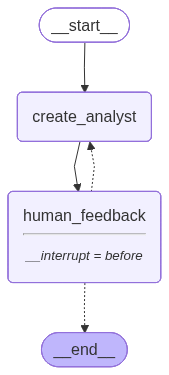

In [20]:
from IPython.display import display , Image
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

In [21]:

topic = "the benefits of adopting Langgraph as an agent framework"
max_analysts = 4
thread =  {"configurable":{"thread_id":1}}
for event in graph.stream({"topic":topic,
              "max_analysts":max_analysts},
             thread,
             stream_mode= "values"):
    analysts = event.get('analysts', '')
    
    if analysts:
        for analyst in analysts:
            print(f"Name: {analyst.name}")
            print(f"Affiliation: {analyst.affiliation}")
            print(f"Role: {analyst.role}")
            print(f"Description: {analyst.description}")
            print("-" * 50)  

HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


Name: Dr. Maya Patel
Affiliation: Institute for Scalable AI Systems
Role: Technical Performance Analyst
Description: Expert in distributed systems and AI agent architectures, focusing on performance benchmarks, latency, and scalability of frameworks like Langgraph.
--------------------------------------------------
Name: Liam Chen
Affiliation: OpenAI Developer Relations
Role: Developer Experience Analyst
Description: Software engineer and community advocate specializing in developer ergonomics, API design, and integration workflows, assessing Langgraph's ease of use.
--------------------------------------------------
Name: Prof. Elena García
Affiliation: AI Community & Open Source Lab, University of Barcelona
Role: Ecosystem & Community Analyst
Description: Researcher studying open‑source ecosystems, community health, and plugin ecosystems, evaluating Langgraph's community support and extensibility.
--------------------------------------------------
Name: Jordan Mitchell
Affiliation: S

In [22]:
state = graph.get_state(thread)
state

StateSnapshot(values={'topic': 'the benefits of adopting Langgraph as an agent framework', 'max_analysts': 4, 'analysts': [Analyst(name='Dr. Maya Patel', role='Technical Performance Analyst', affiliation='Institute for Scalable AI Systems', description='Expert in distributed systems and AI agent architectures, focusing on performance benchmarks, latency, and scalability of frameworks like Langgraph.'), Analyst(name='Liam Chen', role='Developer Experience Analyst', affiliation='OpenAI Developer Relations', description="Software engineer and community advocate specializing in developer ergonomics, API design, and integration workflows, assessing Langgraph's ease of use."), Analyst(name='Prof. Elena García', role='Ecosystem & Community Analyst', affiliation='AI Community & Open Source Lab, University of Barcelona', description="Researcher studying open‑source ecosystems, community health, and plugin ecosystems, evaluating Langgraph's community support and extensibility."), Analyst(name='J

In [23]:
state.values

{'topic': 'the benefits of adopting Langgraph as an agent framework',
 'max_analysts': 4,
 'analysts': [Analyst(name='Dr. Maya Patel', role='Technical Performance Analyst', affiliation='Institute for Scalable AI Systems', description='Expert in distributed systems and AI agent architectures, focusing on performance benchmarks, latency, and scalability of frameworks like Langgraph.'),
  Analyst(name='Liam Chen', role='Developer Experience Analyst', affiliation='OpenAI Developer Relations', description="Software engineer and community advocate specializing in developer ergonomics, API design, and integration workflows, assessing Langgraph's ease of use."),
  Analyst(name='Prof. Elena García', role='Ecosystem & Community Analyst', affiliation='AI Community & Open Source Lab, University of Barcelona', description="Researcher studying open‑source ecosystems, community health, and plugin ecosystems, evaluating Langgraph's community support and extensibility."),
  Analyst(name='Jordan Mitchel

In [24]:
state.next  ##It stops before human feedback

('human_feedback',)

In [25]:
graph.update_state(thread, {"human_analyst_feedback":"along with the generative ai in future tell me the future of indian team"}, as_node="human_feedback")

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f0e7131-c1ed-6b70-8002-fad8f036addb'}}

In [28]:

topic = "the benefits of adopting Langgraph as an agent framework"
max_analysts = 4
thread =  {"configurable":{"thread_id":1}}
for event in graph.stream({"topic":topic,
              "max_analysts":max_analysts},
             thread,
             stream_mode= "values"):
    analysts = event.get('analysts', '')
    
    if analysts:
        for analyst in analysts:
            print(f"Name: {analyst.name}")
            print(f"Affiliation: {analyst.affiliation}")
            print(f"Role: {analyst.role}")
            print(f"Description: {analyst.description}")
            print("-" * 50)  

Name: Dr. Maya Patel
Affiliation: Institute for Scalable AI Systems
Role: Technical Performance Analyst
Description: Expert in distributed systems and AI agent architectures, focusing on performance benchmarks, latency, and scalability of frameworks like Langgraph.
--------------------------------------------------
Name: Liam Chen
Affiliation: OpenAI Developer Relations
Role: Developer Experience Analyst
Description: Software engineer and community advocate specializing in developer ergonomics, API design, and integration workflows, assessing Langgraph's ease of use.
--------------------------------------------------
Name: Prof. Elena García
Affiliation: AI Community & Open Source Lab, University of Barcelona
Role: Ecosystem & Community Analyst
Description: Researcher studying open‑source ecosystems, community health, and plugin ecosystems, evaluating Langgraph's community support and extensibility.
--------------------------------------------------


Name: Jordan Mitchell
Affiliation: Strategic AI Consulting, TechVentures Ltd.
Role: Business & Cost‑Benefit Analyst
Description: Consultant with a background in AI product strategy and ROI analysis, examining the economic impact and adoption incentives of Langgraph for enterprises.
--------------------------------------------------


HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


Name: Dr. Maya Patel
Affiliation: OpenAI Research Lab
Role: Technical Architect
Description: Expert in agent frameworks and distributed systems, with deep knowledge of Langgraph's architecture, scalability, and modular design. Focuses on technical benefits, performance optimization, and best practices for implementation.
--------------------------------------------------
Name: Rajesh Kumar
Affiliation: Infosys AI Solutions
Role: AI Integration Engineer
Description: Specializes in integrating generative AI models with agent orchestration platforms. Provides practical guidance on coupling Langgraph with LLMs, tool use, and end‑to‑end workflow automation.
--------------------------------------------------
Name: Elena Garcia
Affiliation: McKinsey & Company
Role: Business Analyst
Description: Evaluates the business impact of emerging AI technologies. Analyzes ROI, cost‑benefit, adoption roadmaps, and strategic advantages for enterprises adopting Langgraph.
----------------------------------

In [ ]:
state = graph.get_state(thread)
state.values  ###  New Updated values after feedback

{'topic': 'the benefits of adopting Langgraph as an agent framework',
 'max_analysts': 4,
 'human_analyst_feedback': 'along with the generative ai in future tell me the future of indian team',
 'analysts': [Analyst(name='Dr. Maya Patel', role='Technical Architect', affiliation='OpenAI Research Lab', description="Expert in agent frameworks and distributed systems, with deep knowledge of Langgraph's architecture, scalability, and modular design. Focuses on technical benefits, performance optimization, and best practices for implementation."),
  Analyst(name='Rajesh Kumar', role='AI Integration Engineer', affiliation='Infosys AI Solutions', description='Specializes in integrating generative AI models with agent orchestration platforms. Provides practical guidance on coupling Langgraph with LLMs, tool use, and end‑to‑end workflow automation.'),
  Analyst(name='Elena Garcia', role='Business Analyst', affiliation='McKinsey & Company', description='Evaluates the business impact of emerging AI

In [30]:
state.next

('human_feedback',)

In [31]:
graph.update_state(thread, {"human_analyst_feedback":""}, as_node="human_feedback")
graph.get_state(thread).next

()

In [32]:
for event in graph.stream(None, thread, stream_mode="updates"):
    print("--Node--")
    node_name = next(iter(event.keys()))
    print(node_name)

In [33]:
from IPython.display import Markdown
final_state = graph.get_state(thread)
report = final_state.values.get('final_report')

In [37]:
final_state.values

{'topic': 'the benefits of adopting Langgraph as an agent framework',
 'max_analysts': 4,
 'human_analyst_feedback': '',
 'analysts': [Analyst(name='Dr. Maya Patel', role='Technical Architect', affiliation='OpenAI Research Lab', description="Expert in agent frameworks and distributed systems, with deep knowledge of Langgraph's architecture, scalability, and modular design. Focuses on technical benefits, performance optimization, and best practices for implementation."),
  Analyst(name='Rajesh Kumar', role='AI Integration Engineer', affiliation='Infosys AI Solutions', description='Specializes in integrating generative AI models with agent orchestration platforms. Provides practical guidance on coupling Langgraph with LLMs, tool use, and end‑to‑end workflow automation.'),
  Analyst(name='Elena Garcia', role='Business Analyst', affiliation='McKinsey & Company', description='Evaluates the business impact of emerging AI technologies. Analyzes ROI, cost‑benefit, adoption roadmaps, and strate

In [34]:
Markdown(report)

<IPython.core.display.Markdown object>

In [35]:
report

## Second Workflow

In [39]:
from langchain_community.tools.tavily_search import TavilySearchResults
tavily_tool = TavilySearchResults()
tavily_tool.invoke("Langgraph agent framework benefits")   

C:\Users\admin\AppData\Local\Temp\ipykernel_18352\962464785.py:2: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-tavily package and should be used instead. To use it run `pip install -U :class:`~langchain-tavily` and import as `from :class:`~langchain_tavily import TavilySearch``.
  tavily_tool = TavilySearchResults()


[{'title': 'LangGraph: A Framework for Building Stateful Multi-Agent LLM ...',
  'url': 'https://medium.com/@ken_lin/langgraph-a-framework-for-building-stateful-multi-agent-llm-applications-a51d5eb68d03',
  'content': 'The most significant advantage of LangGraph is its explicit support for cyclical workflows, which are essential for implementing agent-like behaviors. As emphasized in the documentation: “Crucially, this is NOT a DAG framework… Cycles are important for agent-like behaviors, where you call an LLM in a loop, asking it what action to take next.” This capability enables the development of sophisticated agents that can iteratively refine their understanding and actions, leading to more capable AI [...] LangGraph provides a clear and intuitive mechanism for defining coordination between multiple agents or components in a system. The graph-based structure visually represents how information flows between components, making it easier to design, implement, and reason about comple

In [70]:
from langchain_community.document_loaders import WikipediaLoader

In [ ]:
from langchain_community.document_loaders import WikipediaLoader
docs = WikipediaLoader(query="Langgraph").load()
print(docs[0].page_content[:500])

LangChain is a software framework that helps facilitate the integration of large language models (LLMs) into applications. As a language model integration framework, LangChain's use-cases largely overlap with those of language models in general, including document analysis and summarization, chatbots, and code analysis.


== History ==
LangChain was launched in October 2022 as an open source project by Harrison Chase, while working at machine learning startup Robust Intelligence. In April 2023, 


In [71]:
import operator
class InterviewState(MessagesState):
    max_num_turns: int = 6
    context: Annotated[list, operator.add]
    analyst: Analyst
    interview: str
    sections: list
class SearchQuery(BaseModel):
    search_query: str = Field(None, description="Search the Query for Retrieval")


In [72]:
question_instructions = """You are an analyst tasked with interviewing an expert to learn about a specific topic. 

Your goal is boil down to interesting and specific insights related to your topic.

1. Interesting: Insights that people will find surprising or non-obvious.
        
2. Specific: Insights that avoid generalities and include specific examples from the expert.

Here is your topic of focus and set of goals: {goals}
        
Begin by introducing yourself using a name that fits your persona, and then ask your question.

Continue to ask questions to drill down and refine your understanding of the topic.
        
When you are satisfied with your understanding, complete the interview with: "Thank you so much for your help!"

Remember to stay in character throughout your response, reflecting the persona and goals provided to you."""

In [43]:
print(analyst.profile)

Arjun Singh, a Future Trends Analyst affiliated with NASSCOM FutureTech. Studies the future of AI development in India, focusing on how frameworks like Langgraph will shape Indian tech teams, talent pipelines, and the broader AI ecosystem.


In [44]:
print(question_instructions.format(goals = analyst.profile))

You are an analyst tasked with interviewing an expert to learn about a specific topic. 

Your goal is boil down to interesting and specific insights related to your topic.

1. Interesting: Insights that people will find surprising or non-obvious.

2. Specific: Insights that avoid generalities and include specific examples from the expert.

Here is your topic of focus and set of goals: Arjun Singh, a Future Trends Analyst affiliated with NASSCOM FutureTech. Studies the future of AI development in India, focusing on how frameworks like Langgraph will shape Indian tech teams, talent pipelines, and the broader AI ecosystem.

Begin by introducing yourself using a name that fits your persona, and then ask your question.

Continue to ask questions to drill down and refine your understanding of the topic.

When you are satisfied with your understanding, complete the interview with: "Thank you so much for your help!"

Remember to stay in character throughout your response, reflecting the person

In [73]:
def generation_question(state:InterviewState):
    """Node to generate the questions"""
    
    #get state
    analyst = state["analyst"]
    messages = state["messages"]
    
    #generate the question
    system_message = question_instructions.format(goals = analyst.profile)
    question = llm.invoke([SystemMessage(content=system_message)]+messages)
    
    #returen the question through state
    return {"messages":[question]}

In [46]:
analyst

Analyst(name='Arjun Singh', role='Future Trends Analyst', affiliation='NASSCOM FutureTech', description='Studies the future of AI development in India, focusing on how frameworks like Langgraph will shape Indian tech teams, talent pipelines, and the broader AI ecosystem.')

In [47]:
state = {"max_num_turns":2,"context":[],"analyst":analyst,"interview":"","section":[],"messages":[HumanMessage(content="hi do the proper search according to the experties")]}
state

{'max_num_turns': 2,
 'context': [],
 'analyst': Analyst(name='Arjun Singh', role='Future Trends Analyst', affiliation='NASSCOM FutureTech', description='Studies the future of AI development in India, focusing on how frameworks like Langgraph will shape Indian tech teams, talent pipelines, and the broader AI ecosystem.'),
 'interview': '',
 'section': [],
 'messages': [HumanMessage(content='hi do the proper search according to the experties', additional_kwargs={}, response_metadata={})]}

In [48]:
result = generation_question(state)
print(result["messages"][0].content)

HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


**Interviewer (Meera Patel, Tech Futures Analyst, BloombergNEF):**  
Hi Arjun, thank you for taking the time to chat. To kick things off, could you give us a brief overview of what Langgraph is and why you think it’s poised to become a pivotal framework for AI development within Indian tech teams?


In [74]:
from langchain_core.messages import get_buffer_string
# Search query writing
search_instructions = SystemMessage(content=f"""You will be given a conversation between an analyst and an expert. 
Your goal is to generate a well-structured query for use in retrieval and / or web-search related to the conversation. 
First, analyze the full conversation.
Pay particular attention to the final question posed by the analyst.
Convert this final question into a well-structured web search query""")
print(search_instructions.content)

You will be given a conversation between an analyst and an expert. 
Your goal is to generate a well-structured query for use in retrieval and / or web-search related to the conversation. 
First, analyze the full conversation.
Pay particular attention to the final question posed by the analyst.
Convert this final question into a well-structured web search query


In [75]:
def search_web(state:InterviewState):
    """
    Retrieve data from the web
    """
    structure_llm = llm.with_structured_output(SearchQuery)
    search_query = structure_llm.invoke([search_instructions]+state["messages"])
    
    # Search
    search_docs = tavily_tool.invoke(search_query.search_query)
    # Format
    formatted_search_docs = "\n\n---\n\n".join(
        [
            f'<Document href="{doc["url"]}"/>\n{doc["content"]}\n</Document>'
            for doc in search_docs
        ]
    )

    return {"context": [formatted_search_docs]}

In [51]:
result = search_web(state)
print(result["context"][0])

HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


<Document href="https://www.thence.digital/blogs/master-advanced-search-techniques-improve-your-online-research"/>
7. Failing to test and iterate: Finally, one of the biggest mistakes in advanced search UX is failing to test and iterate. Even the most well-designed search interfaces can have areas for improvement. To avoid this mistake, test the interface with real users, gather feedback, and iterate on the design based on that feedback.

By avoiding these common mistakes and following best practices, you can create an advanced search interface that is user-friendly, efficient, and effective. [...] ### Conclusion

In conclusion, improving the advanced search user experience is essential for any website to provide its users with the best search functionality. By implementing the best practices and tips outlined in this blog post, you can create a search experience that is intuitive, efficient, and effective. [...] 6. Avoiding Technical Jargon: Advanced search should avoid using technica

In [76]:
def search_wikipedia(state:InterviewState):
    """
    Retrieve data from wiki
    """
    # Search query
    structured_llm = llm.with_structured_output(SearchQuery)
    search_query = structured_llm.invoke([search_instructions]+state['messages'])
    
    print("*******************************")
    print(search_query)
    
    # Search
    search_docs = WikipediaLoader(query=search_query.search_query).load()

     # Format
    formatted_search_docs = "\n\n---\n\n".join(
        [
            f'<Document source="{doc.metadata["source"]}" page="{doc.metadata.get("page", "")}"/>\n{doc.page_content}\n</Document>'
            for doc in search_docs
        ]
    )

    return {"context": [formatted_search_docs]} 

In [169]:
state

{'max_num_turns': 2,
 'context': [],
 'analyst': Analyst(name='Dr. Luis Martínez', role='Comparative Framework Analyst', affiliation='Open‑Source AI Consortium', description='Conducts side‑by‑side benchmarks of agent frameworks (Langgraph, LangChain, AutoGPT, CrewAI). Highlights performance, ecosystem maturity, and community support to guide decision‑makers.'),
 'interview': '',
 'section': [],
 'messages': [HumanMessage(content='hi do the proper search according to the experties', additional_kwargs={}, response_metadata={})]}

In [170]:
result = search_wikipedia(state)
print(result["context"][0])

HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


*******************************
search_query='latest research on expert systems and AI expertise advancements'
<Document source="https://en.wikipedia.org/wiki/OpenAI" page=""/>
OpenAI is an American artificial intelligence (AI) organization headquartered in San Francisco, California. It aims to develop "safe and beneficial" artificial general intelligence (AGI), which it defines as "highly autonomous systems that outperform humans at most economically valuable work". As a leading organization in the ongoing AI boom, OpenAI is known for the GPT family of large language models, the DALL-E series of text-to-image models, and a text-to-video model named Sora. Its release of ChatGPT in November 2022 has been credited with catalyzing widespread interest in generative AI.
The organization was founded in 2015 in Delaware but evolved a complex corporate structure. As of October 2025, following restructuring approved by California and Delaware regulators, the non-profit OpenAI Foundation holds 2

In [77]:
answer_instructions = """You are an expert being interviewed by an analyst.

Here is analyst area of focus: {goals}. 
        
You goal is to answer a question posed by the interviewer.

To answer question, use this context:
        
{context}

When answering questions, follow these guidelines:
        
1. Use only the information provided in the context. 
        
2. Do not introduce external information or make assumptions beyond what is explicitly stated in the context.

3. The context contain sources at the topic of each individual document.

4. Include these sources your answer next to any relevant statements. For example, for source # 1 use [1]. 

5. List your sources in order at the bottom of your answer. [1] Source 1, [2] Source 2, etc
        
6. If the source is: <Document source="assistant/docs/llama3_1.pdf" page="7"/>' then just list: 
        
[1] assistant/docs/llama3_1.pdf, page 7 
        
And skip the addition of the brackets as well as the Document source preamble in your citation."""

In [78]:
def generate_answer(state:InterviewState):
   
    """ Node to answer a question """

    # Get state
    analyst = state["analyst"]
    messages = state["messages"]
    context = state["context"]

    # Answer question
    system_message = answer_instructions.format(goals=analyst.profile, context=context)
    answer = llm.invoke([SystemMessage(content=system_message)]+messages)
            
    # Name the message as coming from the expert
    answer.name = "expert"
    
    # Append it to state
    return {"messages": [answer]}

In [79]:
def save_interview(state: InterviewState):
    
    """ Save interviews """

    # Get messages
    messages = state["messages"]
    
    # Convert interview to a string
    interview = get_buffer_string(messages)
    
    # Save to interviews key
    return {"interview": interview}

In [80]:
def route_messages(state: InterviewState, 
                   name: str = "expert"):

    """ Route between question and answer """
    
    # Get messages
    messages = state["messages"]
    max_num_turns = state.get('max_num_turns',2)

    # Check the number of expert answers 
    num_responses = len(
        [m for m in messages if isinstance(m, AIMessage) and m.name == name]
    )

    # End if expert has answered more than the max turns
    if num_responses >= max_num_turns:
        return 'save_interview'

    # This router is run after each question - answer pair 
    # Get the last question asked to check if it signals the end of discussion
    last_question = messages[-2]
    
    if "Thank you so much for your help" in last_question.content:
        return 'save_interview'
    
    return "ask_question"

In [81]:
section_writer_instructions = """You are an expert technical writer. 
            
Your task is to create a short, easily digestible section of a report based on a set of source documents.

1. Analyze the content of the source documents: 
- The name of each source document is at the start of the document, with the <Document tag.
        
2. Create a report structure using markdown formatting:
- Use ## for the section title
- Use ### for sub-section headers
        
3. Write the report following this structure:
a. Title (## header)
b. Summary (### header)
c. Sources (### header)

4. Make your title engaging based upon the focus area of the analyst: 
{focus}

5. For the summary section:
- Set up summary with general background / context related to the focus area of the analyst
- Emphasize what is novel, interesting, or surprising about insights gathered from the interview
- Create a numbered list of source documents, as you use them
- Do not mention the names of interviewers or experts
- Aim for approximately 400 words maximum
- Use numbered sources in your report (e.g., [1], [2]) based on information from source documents
        
6. In the Sources section:
- Include all sources used in your report
- Provide full links to relevant websites or specific document paths
- Separate each source by a newline. Use two spaces at the end of each line to create a newline in Markdown.
- It will look like:

### Sources
[1] Link or Document name
[2] Link or Document name

7. Be sure to combine sources. For example this is not correct:

[3] https://ai.meta.com/blog/meta-llama-3-1/
[4] https://ai.meta.com/blog/meta-llama-3-1/

There should be no redundant sources. It should simply be:

[3] https://ai.meta.com/blog/meta-llama-3-1/
        
8. Final review:
- Ensure the report follows the required structure
- Include no preamble before the title of the report
- Check that all guidelines have been followed"""

In [82]:
def write_section(state: InterviewState):

    """ Node to answer a question """

    # Get state
    interview = state["interview"]
    context = state["context"]
    analyst = state["analyst"]
   
    # Write section using either the gathered source docs from interview (context) or the interview itself (interview)
    system_message = section_writer_instructions.format(focus=analyst.description)
    section = llm.invoke([SystemMessage(content=system_message)]+[HumanMessage(content=f"Use this source to write your section: {context}")]) 
                
    # Append it to state
    return {"sections": [section.content]}

In [83]:
interview_builder = StateGraph(InterviewState)

In [84]:
interview_builder.add_node("ask_question",generation_question)
interview_builder.add_node("search_web",search_web)
interview_builder.add_node("search_wikipedia",search_wikipedia)
interview_builder.add_node("generate_answer",generate_answer)
interview_builder.add_node("save_interview",save_interview)
interview_builder.add_node("write_section",write_section)

In [85]:
interview_builder.add_edge(START, "ask_question")
interview_builder.add_edge("ask_question","search_web")
interview_builder.add_edge("ask_question","search_wikipedia")
interview_builder.add_edge("search_web","generate_answer")
interview_builder.add_edge("search_wikipedia","generate_answer")
interview_builder.add_conditional_edges("generate_answer",
                           route_messages,
                           ["ask_question",
                            "save_interview"])
interview_builder.add_edge("save_interview","write_section")
interview_builder.add_edge("write_section",END)

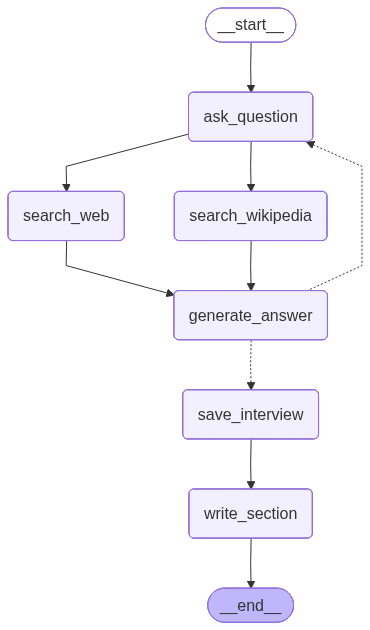

In [86]:
interview_graph = interview_builder.compile(checkpointer=memory).with_config(run_name = "Conduct Interview")
display(Image(interview_graph.get_graph().draw_mermaid_png()))

In [66]:
analyst

Analyst(name='Arjun Singh', role='Future Trends Analyst', affiliation='NASSCOM FutureTech', description='Studies the future of AI development in India, focusing on how frameworks like Langgraph will shape Indian tech teams, talent pipelines, and the broader AI ecosystem.')

In [67]:
analyst.profile

'Arjun Singh, a Future Trends Analyst affiliated with NASSCOM FutureTech. Studies the future of AI development in India, focusing on how frameworks like Langgraph will shape Indian tech teams, talent pipelines, and the broader AI ecosystem.'

In [87]:
thread = {"configurable": {"thread_id": "1"}}

In [88]:
messages = [HumanMessage("So you said you were writing an article on LangGraph?")]
interview = interview_graph.invoke({"analyst": analyst, "messages": messages, "max_num_turns": 2}, thread)

HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


*******************************
search_query='LangGraph case study India product team implementation challenges outcomes'


HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 413 Payload Too Large"


APIStatusError: Error code: 413 - {'error': {'message': 'Request too large for model `openai/gpt-oss-120b` in organization `org_01jk33ssacfe6rdx95961s3mv3` service tier `on_demand` on tokens per minute (TPM): Limit 8000, Requested 14526, please reduce your message size and try again. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}

## Third Workflow

In [211]:
from typing_extensions import TypedDict
from typing import List, Annotated
import operator
class ResearchGraphState(TypedDict):
    topic: str # Research topic
    max_analysts: int # Number of analysts
    human_analyst_feedback: str # Human feedback
    analysts: List[Analyst] # Analyst asking questions
    sections: Annotated[list, operator.add] # Send() API key
    introduction: str # Introduction for the final report
    content: str # Content for the final report
    conclusion: str # Conclusion for the final report
    final_report: str # Final report
    

In [228]:
from langgraph.types import Send

In [229]:
def initiate_all_interviews(state:ResearchGraphState):
    """ This is the "map" step where we run each interview sub-graph using Send API """ 
    
    #check if human feedback
    human_analyst_feedback=state.get('human_analyst_feedback')
    if human_analyst_feedback:
        # Return to create_analysts
        return "create_analysts"
    
    # Otherwise kick off interviews in parallel via Send() API
    else:
        topic = state["topic"]
        return [Send("conduct_interview", {"analyst": analyst,
                                        "messages": [HumanMessage(
                                            content=f"So you said you were writing an article on {topic}?"
                                        )
                                                ]}) for analyst in state["analysts"]]

In [230]:
report_writer_instructions = """You are a technical writer creating a report on this overall topic: 

{topic}
    
You have a team of analysts. Each analyst has done two things: 

1. They conducted an interview with an expert on a specific sub-topic.
2. They write up their finding into a memo.

Your task: 

1. You will be given a collection of memos from your analysts.
2. Think carefully about the insights from each memo.
3. Consolidate these into a crisp overall summary that ties together the central ideas from all of the memos. 
4. Summarize the central points in each memo into a cohesive single narrative.

To format your report:
 
1. Use markdown formatting. 
2. Include no pre-amble for the report.
3. Use no sub-heading. 
4. Start your report with a single title header: ## Insights
5. Do not mention any analyst names in your report.
6. Preserve any citations in the memos, which will be annotated in brackets, for example [1] or [2].
7. Create a final, consolidated list of sources and add to a Sources section with the `## Sources` header.
8. List your sources in order and do not repeat.

[1] Source 1
[2] Source 2

Here are the memos from your analysts to build your report from: 

{context}"""

In [231]:
def write_report(state: ResearchGraphState):
    # Full set of sections
    sections = state["sections"]
    topic = state["topic"]

    # Concat all sections together
    formatted_str_sections = "\n\n".join([f"{section}" for section in sections])
    
    # Summarize the sections into a final report
    system_message = report_writer_instructions.format(topic=topic, context=formatted_str_sections)    
    report = llm.invoke([SystemMessage(content=system_message)]+[HumanMessage(content=f"Write a report based upon these memos.")]) 
    return {"content": report.content}

In [233]:
intro_conclusion_instructions = """You are a technical writer finishing a report on {topic}

You will be given all of the sections of the report.

You job is to write a crisp and compelling introduction or conclusion section.

The user will instruct you whether to write the introduction or conclusion.

Include no pre-amble for either section.

Target around 100 words, crisply previewing (for introduction) or recapping (for conclusion) all of the sections of the report.

Use markdown formatting. 

For your introduction, create a compelling title and use the # header for the title.

For your introduction, use ## Introduction as the section header. 

For your conclusion, use ## Conclusion as the section header.

Here are the sections to reflect on for writing: {formatted_str_sections}"""

In [234]:
def write_introduction(state: ResearchGraphState):
    # Full set of sections
    sections = state["sections"]
    topic = state["topic"]

    # Concat all sections together
    formatted_str_sections = "\n\n".join([f"{section}" for section in sections])
    
    # Summarize the sections into a final report
    
    instructions = intro_conclusion_instructions.format(topic=topic, formatted_str_sections=formatted_str_sections)    
    intro = llm.invoke([instructions]+[HumanMessage(content=f"Write the report introduction")]) 
    return {"introduction": intro.content}

In [235]:
def write_conclusion(state: ResearchGraphState):
    # Full set of sections
    sections = state["sections"]
    topic = state["topic"]

    # Concat all sections together
    formatted_str_sections = "\n\n".join([f"{section}" for section in sections])
    
    # Summarize the sections into a final report
    
    instructions = intro_conclusion_instructions.format(topic=topic, formatted_str_sections=formatted_str_sections)    
    conclusion = llm.invoke([instructions]+[HumanMessage(content=f"Write the report conclusion")]) 
    return {"conclusion": conclusion.content}

In [236]:
def finalize_report(state: ResearchGraphState):
    """ The is the "reduce" step where we gather all the sections, combine them, and reflect on them to write the intro/conclusion """
    # Save full final report
    content = state["content"]
    if content.startswith("## Insights"):
        content = content.strip("## Insights")
    if "## Sources" in content:
        try:
            content, sources = content.split("\n## Sources\n")
        except:
            sources = None
    else:
        sources = None

    final_report = state["introduction"] + "\n\n---\n\n" + content + "\n\n---\n\n" + state["conclusion"]
    if sources is not None:
        final_report += "\n\n## Sources\n" + sources
    return {"final_report": final_report}

In [237]:
# Add nodes and edges 
builder = StateGraph(ResearchGraphState)
builder.add_node("create_analysts", create_analyst)
builder.add_node("human_feedback", human_feedback)
builder.add_node("conduct_interview", interview_builder.compile())
builder.add_node("write_report",write_report)
builder.add_node("write_introduction",write_introduction)
builder.add_node("write_conclusion",write_conclusion)
builder.add_node("finalize_report",finalize_report)

# Logic
builder.add_edge(START, "create_analysts")
builder.add_edge("create_analysts", "human_feedback")
builder.add_conditional_edges("human_feedback", initiate_all_interviews, ["create_analysts", "conduct_interview"])
builder.add_edge("conduct_interview", "write_report")
builder.add_edge("conduct_interview", "write_introduction")
builder.add_edge("conduct_interview", "write_conclusion")
builder.add_edge(["write_conclusion", "write_report", "write_introduction"], "finalize_report")
builder.add_edge("finalize_report", END)

In [238]:
memory = MemorySaver()
graph = builder.compile(interrupt_before=['human_feedback'], checkpointer=memory)

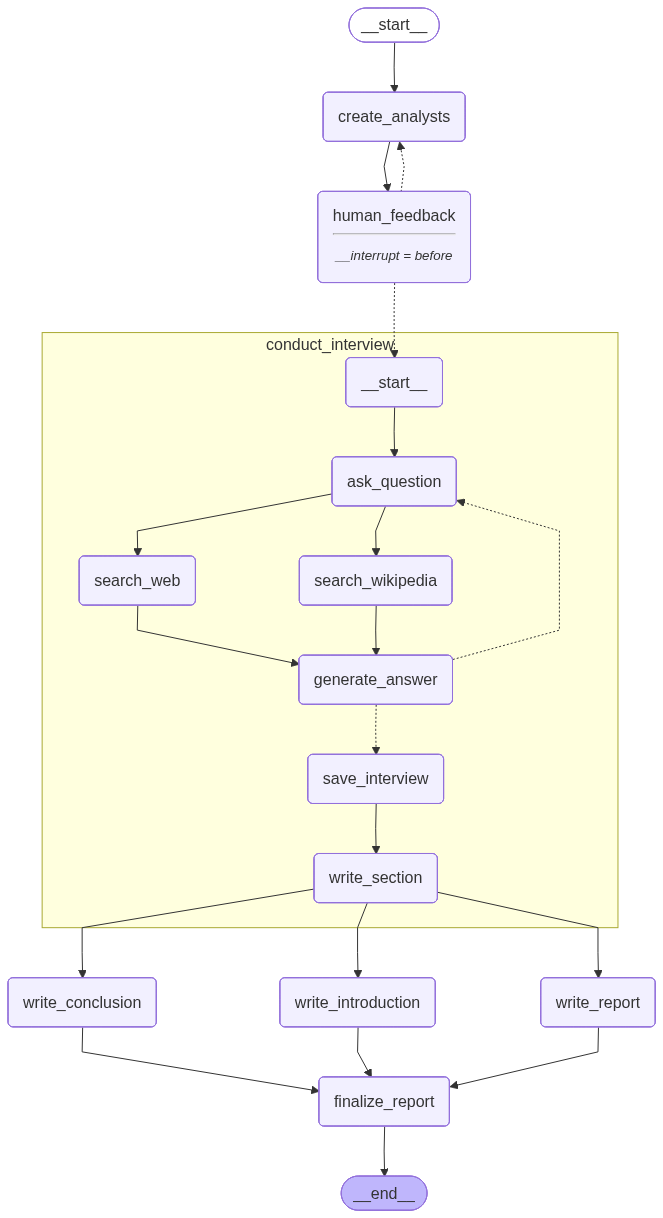

In [239]:
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

In [241]:
max_analysts = 3
topic = "How can generative AI accelerate drug discovery?"
thread = {"configurable": {"thread_id": "1"}}

In [242]:
# Run the graph until the first interruption
for event in graph.stream({"topic":topic,"max_analysts":max_analysts}, thread, stream_mode="values"):
    analysts = event.get('analysts', '')
    if analysts:
        for analyst in analysts:
            print(f"Name: {analyst.name}")
            print(f"Affiliation: {analyst.affiliation}")
            print(f"Role: {analyst.role}")
            print(f"Description: {analyst.description}")
            print("-" * 50) 

Retrying langchain_google_genai.chat_models._chat_with_retry.<locals>._chat_with_retry in 2.0 seconds as it raised ResourceExhausted: 429 You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/usage?tab=rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_input_token_count, limit: 0, model: gemini-2.0-flash
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 0, model: gemini-2.0-flash
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 0, model: gemini-2.0-flash
Please retry in 2.469237508s. [links {
  description: "Learn more about Gemini API quotas"
  url: "https://ai.google.dev/gemini-api/docs/rate-limits"
}
, violations {
  quota_metric: "generativelangua

ResourceExhausted: 429 You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/usage?tab=rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 0, model: gemini-2.0-flash
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 0, model: gemini-2.0-flash
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_input_token_count, limit: 0, model: gemini-2.0-flash
Please retry in 334.187067ms. [links {
  description: "Learn more about Gemini API quotas"
  url: "https://ai.google.dev/gemini-api/docs/rate-limits"
}
, violations {
  quota_metric: "generativelanguage.googleapis.com/generate_content_free_tier_requests"
  quota_id: "GenerateRequestsPerDayPerProjectPerModel-FreeTi